In [1]:
import os
import sys
from pathlib import Path
import logging
import pandas as pd
from dotenv import load_dotenv
import networkx as nx
from typing import Tuple, Any, List, Dict
from IPython.display import IFrame, display, HTML
import json
import math
# Reduce logging noise
logging.getLogger().setLevel(logging.WARNING)

ROOT_DIR = Path(os.getcwd())
if ROOT_DIR.name == "notebooks":
    ROOT_DIR = ROOT_DIR.parent
sys.path.insert(0, str(ROOT_DIR / "src"))

from graph_generation.sbfl.extractor import ExtractionResult
from visualization.graph_plots import plot_json_graph
from cut_algorithms.boykov_jolly import BoykovJollyCut
from cut_algorithms.data_parsers import read_call_graph
from cut_algorithms.data_parsers import compute_method_tarantula


In [2]:
import pandas as pd
import json
import ast
from pathlib import Path

# Set up paths - adjust base_dir if your notebook is not in the project root
base_dir = Path("/Users/ashish/master-thesis/Master-Thesis/failure-propagation-and-rca-via-energy-minimization")
outputs_dir = base_dir / "outputs" / "d4j"
ground_truth_path = base_dir / "ground_truth.csv"

# 1. Load Ground Truth to find Buggy Nodes
df_gt = pd.read_csv(ground_truth_path)

def get_buggy_methods(project, bug_id):
    """Helper to extract the exact buggy methods string from ground truth."""
    buggy_str = df_gt[(df_gt['project'] == project) & (df_gt['bug_id'] == bug_id)]['buggy_nodes'].values[0]
    return ast.literal_eval(buggy_str)


def compile_analysis_from_disk(lambdas=[0.0, 0.1, 1.0]):
    """Iterates over the disk artifacts and builds the master DataFrame."""
    records = []
    
    for lambd_val in lambdas:
        lambd_dir = outputs_dir / f"eval_lambd_{lambd_val}"
        
        if not lambd_dir.exists():
            print(f"Skipping lambda={lambd_val}, directory not found.")
            continue
            
        # Iterate over all result CSVs in this lambda directory
        for res_csv in lambd_dir.glob("*.csv"):
            parts = res_csv.stem.split("_")
            project = parts[0]
            bug_id = int(parts[1])
            
            try:
                # Get buggy methods (for single-bug instances, take the first one)
                b_node = get_buggy_methods(project, bug_id)[0]
                
                # --- 1. Load Evaluation Results ---
                res_df = pd.read_csv(res_csv)
                b_results = res_df[res_df['Method'] == b_node]
                if b_results.empty:
                    continue
                b_results = b_results.iloc[0]
                
                # --- 2. Load Node Topological Properties ---
                topo_csv = outputs_dir / "graph_properties" / f"{project}_{bug_id}_topological.csv"
                if not topo_csv.exists():
                    continue
                    
                topo_df = pd.read_csv(topo_csv)
                b_topo = topo_df[topo_df['Method'] == b_node]
                if b_topo.empty:
                    continue
                b_topo = b_topo.iloc[0]
                
                # --- 3. Load Global Network Properties ---
                net_json = outputs_dir / "graph_properties" / f"{project}_{bug_id}_network.json"
                if not net_json.exists():
                    continue
                    
                with open(net_json, 'r') as f:
                    net_dict = json.load(f)
                    
                # --- 4. Combine into single flat record ---
                record = {
                    'project': project,
                    'bug_id': bug_id,
                    'lambda_val': lambd_val,
                    'buggy_node': b_node,
                    
                    # Scores
                    'tarantula': b_results['tarantula'],
                    'tarantula_gc': b_results['tarantula_gc'],
                    'ochiai': b_results['ochiai'],
                    'ochiai_gc': b_results['ochiai_gc'],
                    'dstar': b_results['dstar'],
                    'dstar_gc': b_results['dstar_gc'],
                    
                    # Ranks
                    'tarantula_rank': b_results['tarantula_rank'],
                    'tarantula_gc_rank': b_results['tarantula_gc_rank'],
                    'ochiai_rank': b_results['ochiai_rank'],
                    'ochiai_gc_rank': b_results['ochiai_gc_rank'],
                    'dstar_rank': b_results['dstar_rank'],
                    'dstar_gc_rank': b_results['dstar_gc_rank'],
                    
                    # Rank Gains (Positive means the graph-cut algorithm improved the rank)
                    'rank_gain_tarantula': b_results['tarantula_rank'] - b_results['tarantula_gc_rank'],
                    'rank_gain_ochiai': b_results['ochiai_rank'] - b_results['ochiai_gc_rank'],
                    'rank_gain_dstar': b_results['dstar_rank'] - b_results['dstar_gc_rank'],
                    
                    # EXAM Scores (Expected Inspection fraction)
                    'tarantula_exam_score': b_results['tarantula_exam_score'],
                    'tarantula_gc_exam_score': b_results['tarantula_gc_exam_score']
                }
                
                # Dump all topological metrics dynamically
                for col in topo_df.columns:
                    if col != 'Method': 
                        record[col] = b_topo[col]
                    
                # Dump all network metrics dynamically
                for key, val in net_dict.items():
                    record[key] = val
                    
                records.append(record)
                
            except Exception as e:
                print(f"Error processing {project}_{bug_id}: {e}")
                
    return pd.DataFrame(records)

# Build and display the master dataframe
analysis_df = compile_analysis_from_disk()
display(analysis_df)


Error processing Collections_11: list index out of range
Error processing Math_78: list index out of range
Error processing JxPath_12: list index out of range
Error processing Codec_17: list index out of range
Error processing Lang_54: list index out of range
Error processing JacksonDatabind_21: list index out of range
Error processing JxPath_6: list index out of range
Error processing Compress_39: list index out of range
Error processing Jsoup_17: list index out of range
Error processing JacksonDatabind_20: list index out of range
Error processing Collections_11: list index out of range
Error processing Math_78: list index out of range
Error processing JxPath_12: list index out of range
Error processing Lang_54: list index out of range
Error processing Codec_17: list index out of range
Error processing JacksonDatabind_21: list index out of range
Error processing Jsoup_17: list index out of range
Error processing Compress_39: list index out of range
Error processing JxPath_6: list inde

,project,bug_id,lambda_val,buggy_node,tarantula,tarantula_gc,ochiai,ochiai_gc,dstar,dstar_gc,...,Num_Nodes,Num_Edges,Density,Is_DAG,Reciprocity,Num_SCC,Num_WCC,Degree_Assortativity,Largest_SCC_Avg_Path_Length,Largest_SCC_Diameter
0,Time,25,0.0,org.joda.time.DateTimeZone#getOffsetFromLocal(...,0.833974,1.614060,0.175154,-1.549528,0.791209,1.332227,...,651,1234,0.002916,False,0.003241,649,11,-0.090694,1.000000,1
1,Math,73,0.0,org.apache.commons.math.analysis.solvers.Brent...,0.999532,7.667158,0.707107,0.881374,1.000000,27.631043,...,31,43,0.046237,True,0.000000,31,3,0.455095,0.000000,0
2,Compress,46,0.0,org.apache.commons.compress.archivers.zip.X545...,0.920043,2.442927,0.100000,-2.197225,0.037037,-3.258097,...,233,356,0.006586,True,0.000000,233,12,-0.166774,0.000000,0
3,Jsoup,35,0.0,org.jsoup.parser.HtmlTreeBuilderState.7#proces...,0.558989,0.237059,0.056344,-2.818293,0.003185,-5.746203,...,599,1401,0.003911,False,0.021413,564,13,-0.212458,2.705645,5
4,Lang,42,0.0,org.apache.commons.lang.Entities#escape(java.i...,0.941713,2.782324,0.085126,-2.374658,0.037037,-3.258097,...,54,48,0.016771,True,0.000000,54,8,-0.079057,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,Jsoup,51,1.0,org.jsoup.parser.CharacterReader#matchesLetter(),0.565789,-4.163423,0.052414,-7.322855,0.002755,-10.319760,...,664,1483,0.003369,False,0.018881,627,16,-0.196471,2.767380,5
233,Lang,44,1.0,org.apache.commons.lang.NumberUtils#createNumb...,0.975519,0.510815,0.120386,-7.066110,0.041667,-8.212823,...,20,10,0.026316,True,0.000000,20,10,NaN,0.000000,0
234,Csv,5,1.0,org.apache.commons.csv.CSVPrinter#println(),0.875000,2.646409,0.196116,-2.111247,0.040000,-3.878553,...,36,37,0.029365,True,0.000000,36,4,-0.393703,0.000000,0
235,Chart,12,1.0,org.jfree.chart.plot.MultiplePiePlot#MultipleP...,0.998335,9.737067,0.500000,-2.715769,0.333333,-3.720821,...,184,239,0.007098,False,0.033473,172,15,-0.217996,2.948718,7


In [3]:
analysis_df.columns

Index(['project', 'bug_id', 'lambda_val', 'buggy_node', 'tarantula',
       'tarantula_gc', 'ochiai', 'ochiai_gc', 'dstar', 'dstar_gc',
       'tarantula_rank', 'tarantula_gc_rank', 'ochiai_rank', 'ochiai_gc_rank',
       'dstar_rank', 'dstar_gc_rank', 'rank_gain_tarantula',
       'rank_gain_ochiai', 'rank_gain_dstar', 'tarantula_exam_score',
       'tarantula_gc_exam_score', 'In_Degree', 'Out_Degree',
       'In_Degree_Centrality', 'Out_Degree_Centrality',
       'Betweenness_Centrality', 'Closeness_Centrality', 'PageRank',
       'Clustering_Coefficient', 'Num_Nodes', 'Num_Edges', 'Density', 'Is_DAG',
       'Reciprocity', 'Num_SCC', 'Num_WCC', 'Degree_Assortativity',
       'Largest_SCC_Avg_Path_Length', 'Largest_SCC_Diameter'],
      dtype='object')

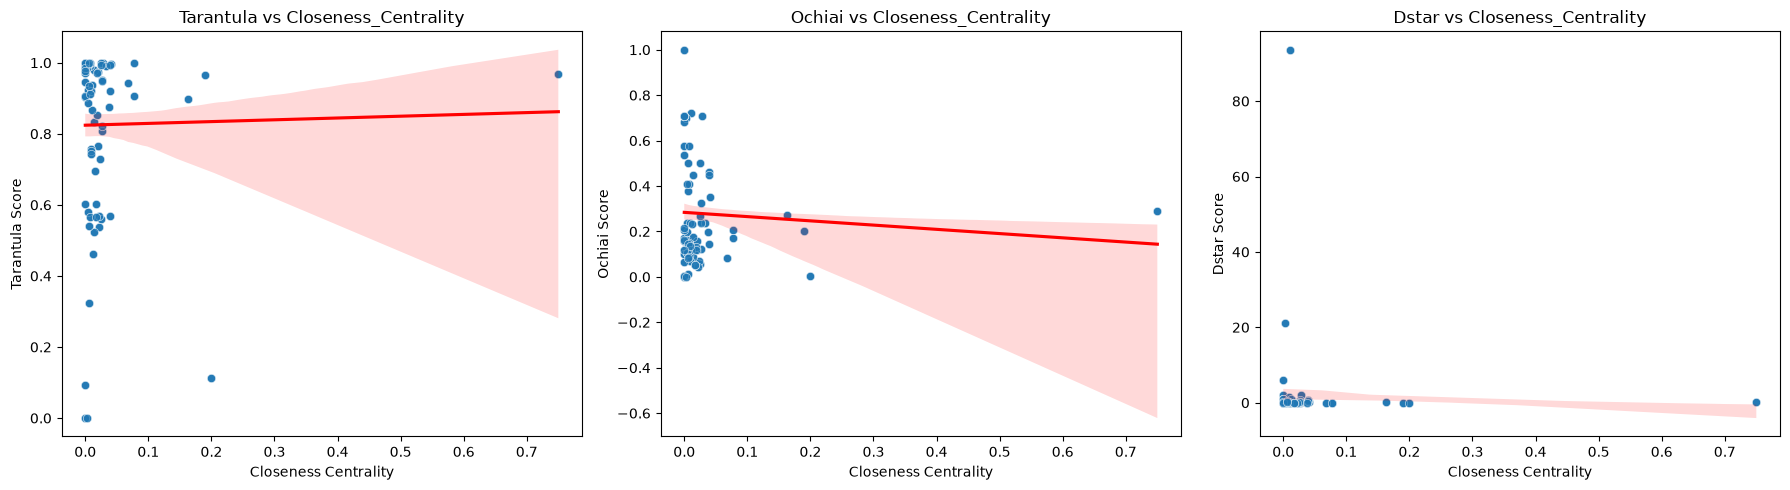

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_baselines_vs_node_topo(df, topo_metric='In_Degree'):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    baselines = ['tarantula', 'ochiai', 'dstar']
    
    for ax, baseline in zip(axes, baselines):
        sns.scatterplot(data=df, x=topo_metric, y=baseline, ax=ax, alpha=0.7)
        sns.regplot(data=df, x=topo_metric, y=baseline, ax=ax, scatter=False, color='red')
        
        ax.set_title(f'{baseline.capitalize()} vs {topo_metric}')
        ax.set_xlabel(topo_metric.replace('_', ' '))
        ax.set_ylabel(baseline.capitalize() + ' Score')
        
    plt.tight_layout()
    plt.show()


plot_baselines_vs_node_topo(analysis_df, topo_metric='Closeness_Centrality')

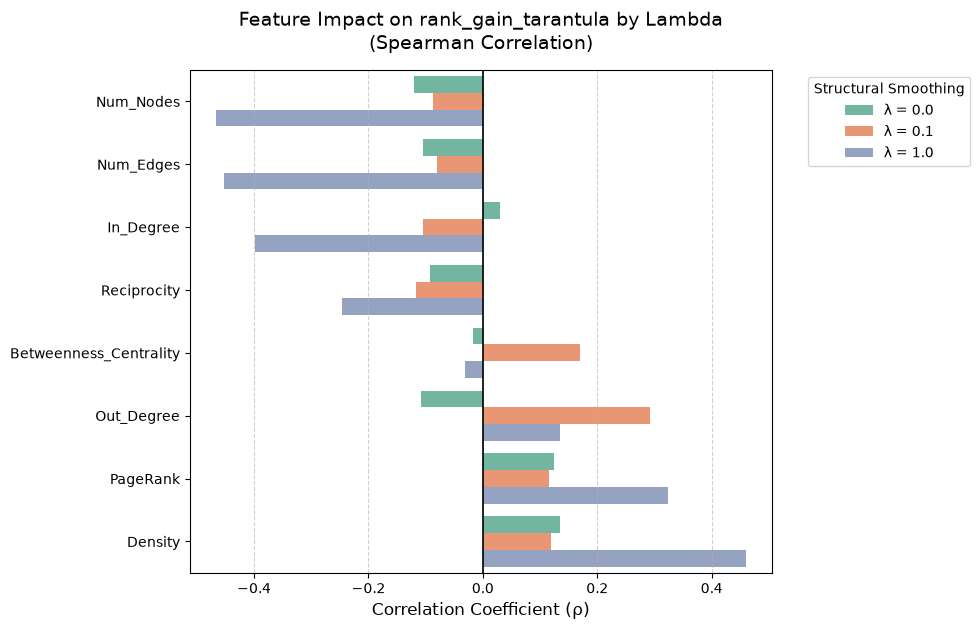

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_correlation_by_lambda(df, feature_cols, target_col='rank_gain_tarantula'):
    """
    Calculates and plots the Spearman correlation of a list of features 
    against a target metric, grouped by the lambda value.
    """
    # 1. Ensure the target column exists
    if target_col not in df.columns:
        print(f"'{target_col}' not found. Calculating as 'tarantula_rank' - 'GraphCut_Rank'...")
        df[target_col] = df['tarantula_rank'] - df['GraphCut_Rank']
        
    # 2. Calculate correlations separately for each lambda
    corr_data = []
    lambdas = sorted(df['lambda_val'].unique())
    
    for l_val in lambdas:
        # Filter dataframe for this specific lambda run
        df_lambda = df[df['lambda_val'] == l_val]
        
        # Calculate Spearman correlations safely
        corrs = df_lambda[feature_cols + [target_col]].corr(method='spearman')[target_col]
        
        # Store results in a flat list of dictionaries for Seaborn
        for feature in feature_cols:
            corr_data.append({
                'Feature': feature,
                'Lambda': f"λ = {l_val}",
                'Correlation': corrs[feature]
            })
            
    # Convert to a DataFrame for easy plotting
    corr_df = pd.DataFrame(corr_data)
    
    # Sort features by their *average* correlation across all lambdas to keep the plot neat
    avg_corrs = corr_df.groupby('Feature')['Correlation'].mean().sort_values()
    
    # 3. Create the grouped bar plot
    # Dynamically scale height based on number of features
    plt.figure(figsize=(10, max(6, len(feature_cols) * 0.8)))
    
    # Seaborn handles the side-by-side grouping automatically via the 'hue' parameter
    ax = sns.barplot(
        data=corr_df, 
        y='Feature', 
        x='Correlation', 
        hue='Lambda', 
        order=avg_corrs.index,
        palette='Set2' # Distinct colors for different lambdas
    )
    
    # 4. Formatting and aesthetics
    plt.axvline(0, color='black', linewidth=1.2)
    plt.title(f"Feature Impact on {target_col} by Lambda\n(Spearman Correlation)", fontsize=14, pad=15)
    plt.xlabel("Correlation Coefficient (ρ)", fontsize=12)
    plt.ylabel("") # Clear the y-axis label since feature names are self-explanatory
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    
    # Add a clean legend
    plt.legend(title="Structural Smoothing", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

# ==========================================
# Example Usage:
# ==========================================
features_to_test = [
    'Num_Nodes', 'Num_Edges', 'Density', 'Reciprocity', 
    'In_Degree', 'Out_Degree', 'PageRank', 'Betweenness_Centrality'
]

plot_correlation_by_lambda(analysis_df, features_to_test)

In [6]:
analysis_df

,project,bug_id,lambda_val,buggy_node,tarantula,tarantula_gc,ochiai,ochiai_gc,dstar,dstar_gc,...,Num_Nodes,Num_Edges,Density,Is_DAG,Reciprocity,Num_SCC,Num_WCC,Degree_Assortativity,Largest_SCC_Avg_Path_Length,Largest_SCC_Diameter
0,Time,25,0.0,org.joda.time.DateTimeZone#getOffsetFromLocal(...,0.833974,1.614060,0.175154,-1.549528,0.791209,1.332227,...,651,1234,0.002916,False,0.003241,649,11,-0.090694,1.000000,1
1,Math,73,0.0,org.apache.commons.math.analysis.solvers.Brent...,0.999532,7.667158,0.707107,0.881374,1.000000,27.631043,...,31,43,0.046237,True,0.000000,31,3,0.455095,0.000000,0
2,Compress,46,0.0,org.apache.commons.compress.archivers.zip.X545...,0.920043,2.442927,0.100000,-2.197225,0.037037,-3.258097,...,233,356,0.006586,True,0.000000,233,12,-0.166774,0.000000,0
3,Jsoup,35,0.0,org.jsoup.parser.HtmlTreeBuilderState.7#proces...,0.558989,0.237059,0.056344,-2.818293,0.003185,-5.746203,...,599,1401,0.003911,False,0.021413,564,13,-0.212458,2.705645,5
4,Lang,42,0.0,org.apache.commons.lang.Entities#escape(java.i...,0.941713,2.782324,0.085126,-2.374658,0.037037,-3.258097,...,54,48,0.016771,True,0.000000,54,8,-0.079057,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,Jsoup,51,1.0,org.jsoup.parser.CharacterReader#matchesLetter(),0.565789,-4.163423,0.052414,-7.322855,0.002755,-10.319760,...,664,1483,0.003369,False,0.018881,627,16,-0.196471,2.767380,5
233,Lang,44,1.0,org.apache.commons.lang.NumberUtils#createNumb...,0.975519,0.510815,0.120386,-7.066110,0.041667,-8.212823,...,20,10,0.026316,True,0.000000,20,10,NaN,0.000000,0
234,Csv,5,1.0,org.apache.commons.csv.CSVPrinter#println(),0.875000,2.646409,0.196116,-2.111247,0.040000,-3.878553,...,36,37,0.029365,True,0.000000,36,4,-0.393703,0.000000,0
235,Chart,12,1.0,org.jfree.chart.plot.MultiplePiePlot#MultipleP...,0.998335,9.737067,0.500000,-2.715769,0.333333,-3.720821,...,184,239,0.007098,False,0.033473,172,15,-0.217996,2.948718,7


In [7]:
analysis_df.columns

Index(['project', 'bug_id', 'lambda_val', 'buggy_node', 'tarantula',
       'tarantula_gc', 'ochiai', 'ochiai_gc', 'dstar', 'dstar_gc',
       'tarantula_rank', 'tarantula_gc_rank', 'ochiai_rank', 'ochiai_gc_rank',
       'dstar_rank', 'dstar_gc_rank', 'rank_gain_tarantula',
       'rank_gain_ochiai', 'rank_gain_dstar', 'tarantula_exam_score',
       'tarantula_gc_exam_score', 'In_Degree', 'Out_Degree',
       'In_Degree_Centrality', 'Out_Degree_Centrality',
       'Betweenness_Centrality', 'Closeness_Centrality', 'PageRank',
       'Clustering_Coefficient', 'Num_Nodes', 'Num_Edges', 'Density', 'Is_DAG',
       'Reciprocity', 'Num_SCC', 'Num_WCC', 'Degree_Assortativity',
       'Largest_SCC_Avg_Path_Length', 'Largest_SCC_Diameter'],
      dtype='object')

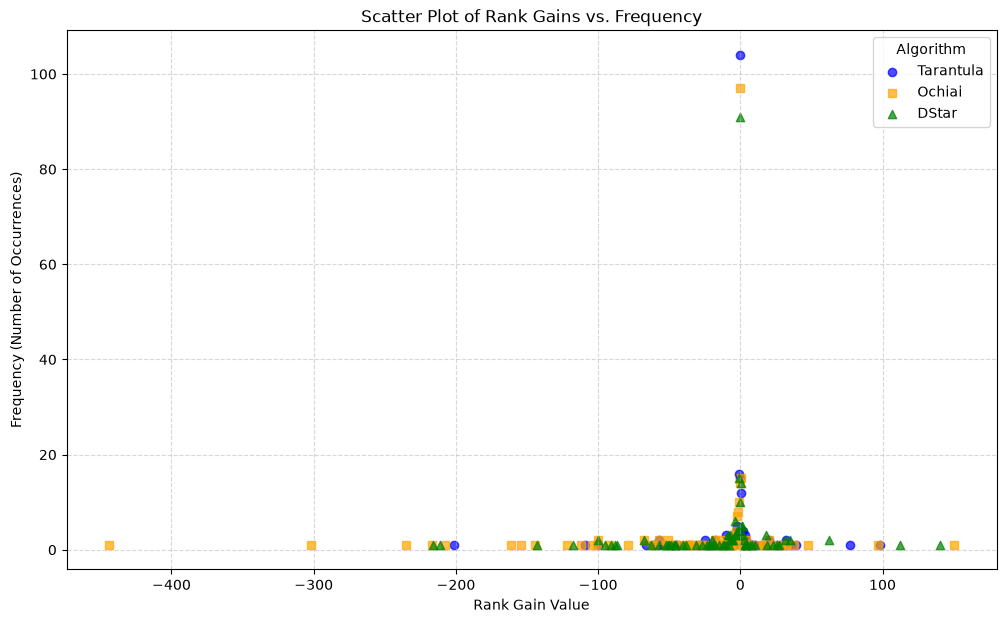

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Calculate the frequency (count) of each unique gain value
tarantula_freq = analysis_df['rank_gain_tarantula'].value_counts().sort_index()
ochiai_freq = analysis_df['rank_gain_ochiai'].value_counts().sort_index()
dstar_freq = analysis_df['rank_gain_dstar'].value_counts().sort_index()

# 2. Create the scatter plot
plt.figure(figsize=(12, 7))

# Plot Tarantula frequencies
plt.scatter(tarantula_freq.index, tarantula_freq.values, 
            color='blue', label='Tarantula', alpha=0.7, marker='o')

# Plot Ochiai frequencies
plt.scatter(ochiai_freq.index, ochiai_freq.values, 
            color='orange', label='Ochiai', alpha=0.7, marker='s')

# Plot DStar frequencies
plt.scatter(dstar_freq.index, dstar_freq.values, 
            color='green', label='DStar', alpha=0.7, marker='^')

# 3. Add titles and labels
plt.title('Scatter Plot of Rank Gains vs. Frequency')
plt.xlabel('Rank Gain Value')
plt.ylabel('Frequency (Number of Occurrences)')

# Add legend and grid
plt.legend(title="Algorithm")
plt.grid(True, linestyle='--', alpha=0.5)

# 4. Display the plot
plt.show()

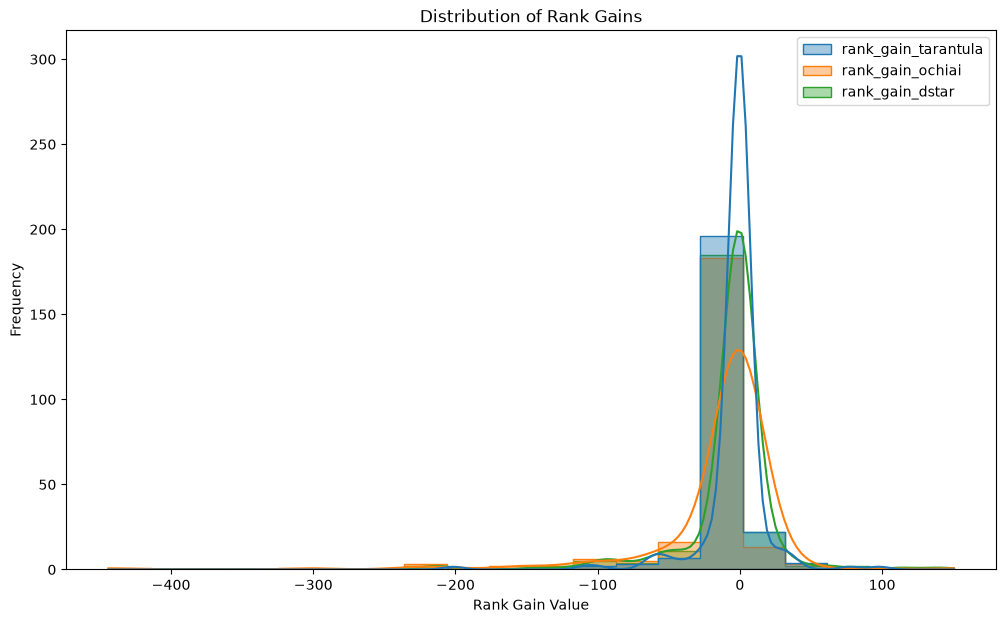

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Select the columns to plot
columns_to_plot = ['rank_gain_tarantula', 'rank_gain_ochiai', 'rank_gain_dstar']

# Create the histogram
# element="step" draws the outlines of the histograms which is cleaner for overlaps
# kde=True adds a smoothed line for the distribution
sns.histplot(data=analysis_df[columns_to_plot], bins=20, kde=True, element="step", alpha=0.4)

plt.title('Distribution of Rank Gains')
plt.xlabel('Rank Gain Value')
plt.ylabel('Frequency')

plt.show()

In [10]:
analysis_df

,project,bug_id,lambda_val,buggy_node,tarantula,tarantula_gc,ochiai,ochiai_gc,dstar,dstar_gc,...,Num_Nodes,Num_Edges,Density,Is_DAG,Reciprocity,Num_SCC,Num_WCC,Degree_Assortativity,Largest_SCC_Avg_Path_Length,Largest_SCC_Diameter
0,Time,25,0.0,org.joda.time.DateTimeZone#getOffsetFromLocal(...,0.833974,1.614060,0.175154,-1.549528,0.791209,1.332227,...,651,1234,0.002916,False,0.003241,649,11,-0.090694,1.000000,1
1,Math,73,0.0,org.apache.commons.math.analysis.solvers.Brent...,0.999532,7.667158,0.707107,0.881374,1.000000,27.631043,...,31,43,0.046237,True,0.000000,31,3,0.455095,0.000000,0
2,Compress,46,0.0,org.apache.commons.compress.archivers.zip.X545...,0.920043,2.442927,0.100000,-2.197225,0.037037,-3.258097,...,233,356,0.006586,True,0.000000,233,12,-0.166774,0.000000,0
3,Jsoup,35,0.0,org.jsoup.parser.HtmlTreeBuilderState.7#proces...,0.558989,0.237059,0.056344,-2.818293,0.003185,-5.746203,...,599,1401,0.003911,False,0.021413,564,13,-0.212458,2.705645,5
4,Lang,42,0.0,org.apache.commons.lang.Entities#escape(java.i...,0.941713,2.782324,0.085126,-2.374658,0.037037,-3.258097,...,54,48,0.016771,True,0.000000,54,8,-0.079057,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,Jsoup,51,1.0,org.jsoup.parser.CharacterReader#matchesLetter(),0.565789,-4.163423,0.052414,-7.322855,0.002755,-10.319760,...,664,1483,0.003369,False,0.018881,627,16,-0.196471,2.767380,5
233,Lang,44,1.0,org.apache.commons.lang.NumberUtils#createNumb...,0.975519,0.510815,0.120386,-7.066110,0.041667,-8.212823,...,20,10,0.026316,True,0.000000,20,10,NaN,0.000000,0
234,Csv,5,1.0,org.apache.commons.csv.CSVPrinter#println(),0.875000,2.646409,0.196116,-2.111247,0.040000,-3.878553,...,36,37,0.029365,True,0.000000,36,4,-0.393703,0.000000,0
235,Chart,12,1.0,org.jfree.chart.plot.MultiplePiePlot#MultipleP...,0.998335,9.737067,0.500000,-2.715769,0.333333,-3.720821,...,184,239,0.007098,False,0.033473,172,15,-0.217996,2.948718,7


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_gains_for_lambda(df, lambda_val):
    """
    Plots a histogram of rank gains for a specific lambda value.
    """
    # Filter the dataframe for the specified lambda_val
    filtered_df = df[df['lambda_val'] == lambda_val]
    
    # Safety check in case the lambda_val doesn't exist
    if filtered_df.empty:
        print(f"No data found for lambda_val = {lambda_val}")
        return
    
    # Set up the plot
    plt.figure(figsize=(10, 6))
    columns_to_plot = ['rank_gain_tarantula', 'rank_gain_ochiai', 'rank_gain_dstar']
    
    # Create the histogram
    sns.histplot(
        data=filtered_df[columns_to_plot], 
        element="step", 
        kde=True, 
        alpha=0.4
    )
    
    # Add labels and title
    plt.title(f'Distribution of Rank Gains for lambda_val = {lambda_val}')
    plt.xlabel('Rank Gain Value')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    # Display the plot
    plt.show()


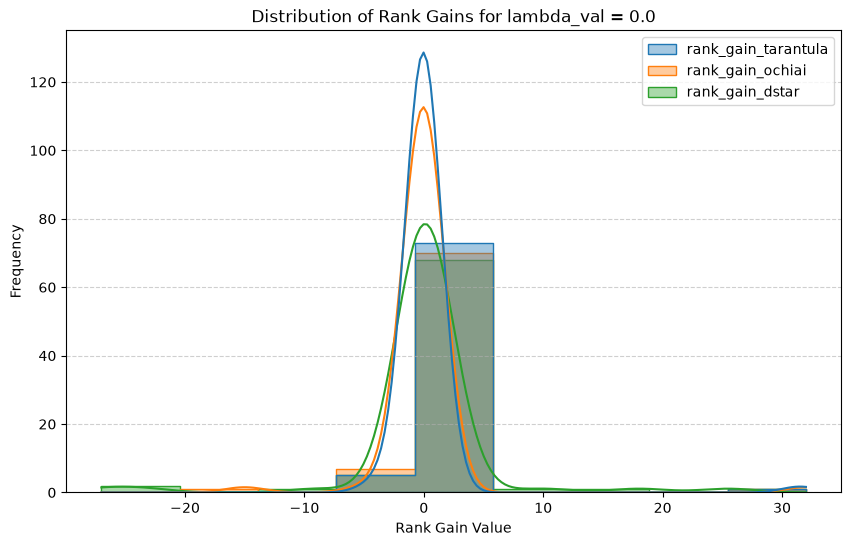

In [16]:
plot_gains_for_lambda(analysis_df, 0.0)

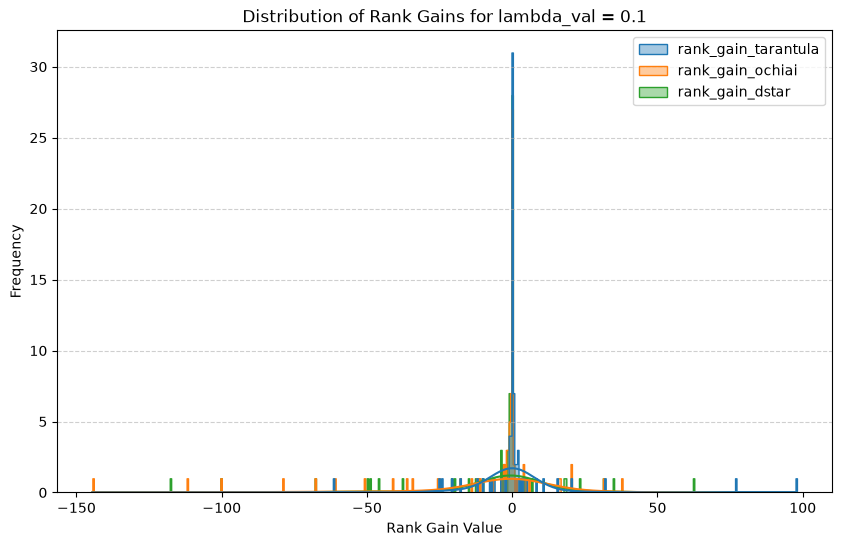

In [17]:
plot_gains_for_lambda(analysis_df, 0.1)

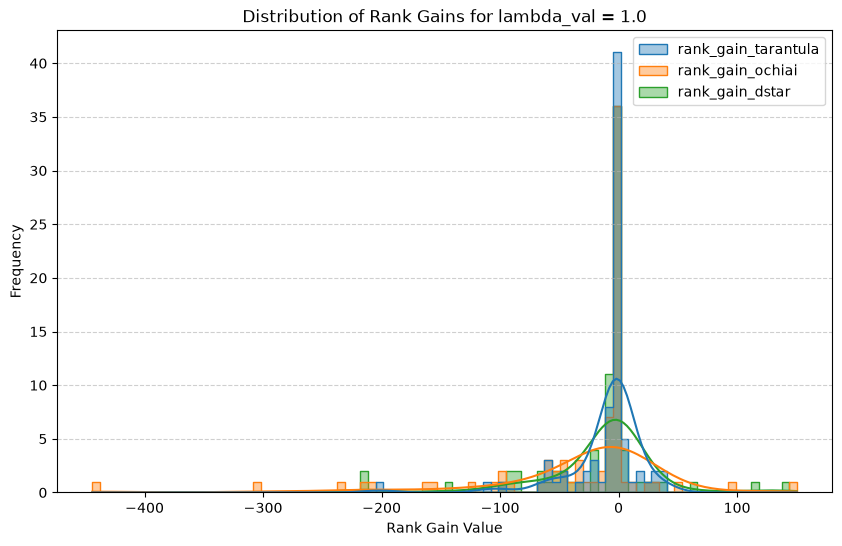

In [18]:
plot_gains_for_lambda(analysis_df, 1.0)

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_gains_for_project(df, project_name):
    """
    Plots a histogram of rank gains for a specific project.
    """
    # Filter the dataframe for the specified project
    filtered_df = df[df['project'] == project_name]
    
    # Safety check
    if filtered_df.empty:
        print(f"No data found for project = '{project_name}'")
        return
    
    plt.figure(figsize=(10, 6))
    columns_to_plot = ['rank_gain_tarantula', 'rank_gain_ochiai', 'rank_gain_dstar']
    
    # Create the histogram
    sns.histplot(
        data=filtered_df[columns_to_plot], 
        element="step", 
        kde=True, 
        alpha=0.4
    )
    
    plt.title(f'Distribution of Rank Gains for Project: {project_name}')
    plt.xlabel('Rank Gain Value')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    plt.show()


,project,bug_id,lambda_val,buggy_node,tarantula,tarantula_gc,ochiai,ochiai_gc,dstar,dstar_gc,...,Num_Nodes,Num_Edges,Density,Is_DAG,Reciprocity,Num_SCC,Num_WCC,Degree_Assortativity,Largest_SCC_Avg_Path_Length,Largest_SCC_Diameter
79,JacksonDatabind,8,0.1,com.fasterxml.jackson.databind.deser.impl.Crea...,0.579039,0.351683,0.105139,-2.211283,0.284706,-0.948144,...,1048,1800,0.001640,False,0.004444,1033,14,-0.105498,3.893939,8
80,Csv,3,0.1,org.apache.commons.csv.Lexer#readEscape(),0.920863,2.559406,0.462910,-0.253904,0.818182,1.398806,...,85,93,0.013025,False,0.000000,85,10,0.006158,0.000000,0
81,Lang,42,0.1,org.apache.commons.lang.Entities#escape(java.i...,0.941713,2.841261,0.085126,-2.475118,0.037037,-3.358556,...,54,48,0.016771,True,0.000000,54,8,-0.079057,0.000000,0
82,Jsoup,35,0.1,org.jsoup.parser.HtmlTreeBuilderState.7#proces...,0.558989,1.402766,0.056344,-5.128730,0.003185,-8.056640,...,599,1401,0.003911,False,0.021413,564,13,-0.212458,2.705645,5
83,Compress,46,0.1,org.apache.commons.compress.archivers.zip.X545...,0.920043,2.442927,0.100000,-2.266709,0.037037,-3.327581,...,233,356,0.006586,True,0.000000,233,12,-0.166774,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,JacksonDatabind,16,0.1,com.fasterxml.jackson.databind.introspect.Anno...,0.567381,0.325802,0.146975,-1.813156,0.595721,0.405875,...,487,686,0.002898,False,0.000000,484,15,-0.191757,2.000000,3
154,Codec,7,0.1,org.apache.commons.codec.binary.Base64#encodeB...,0.993377,5.058691,0.707107,0.833317,2.000000,27.582987,...,45,54,0.027273,False,0.000000,45,2,-0.115999,0.000000,0
155,Gson,17,0.1,com.google.gson.DefaultDateTypeAdapter#read(co...,0.992293,4.881148,0.447214,-0.491003,0.500000,-0.279068,...,35,33,0.027731,False,0.000000,35,4,-0.318073,0.000000,0
156,Time,20,0.1,org.joda.time.format.DateTimeFormatterBuilder....,0.995859,5.608720,0.235702,-1.302388,0.111111,-2.205441,...,528,898,0.003227,False,0.004454,526,20,-0.124385,1.000000,1


In [37]:
analysis_df.project.value_counts()

project
Math               39
Jsoup              36
Chart              21
Time               18
Compress           18
Lang               18
Csv                15
JacksonDatabind    15
Codec              15
Mockito            12
JacksonCore         9
Collections         6
Cli                 6
Gson                6
JacksonXml          3
Name: count, dtype: int64

In [36]:
analysis_df[analysis_df['lambda_val']==1.0].rank_gain_tarantula.value_counts()

rank_gain_tarantula
 0.0      13
-1.0      10
-2.0       4
-0.5       4
-3.0       3
-2.5       2
 3.0       2
 1.5       2
-10.0      2
-57.0      2
-5.0       2
-29.0      1
-20.0      1
 8.5       1
 2.5       1
-15.0      1
 32.0      1
-25.0      1
-1.5       1
 20.5      1
 2.0       1
-100.0     1
-6.0       1
 39.0      1
-36.0      1
-58.0      1
 0.5       1
 25.5      1
 35.5      1
-4.5       1
 18.5      1
-44.0      1
-5.5       1
-66.0      1
-109.5     1
-7.0       1
-54.0      1
 4.0       1
-6.5       1
-22.0      1
-18.0      1
 28.5      1
-45.0      1
-201.5     1
Name: count, dtype: int64

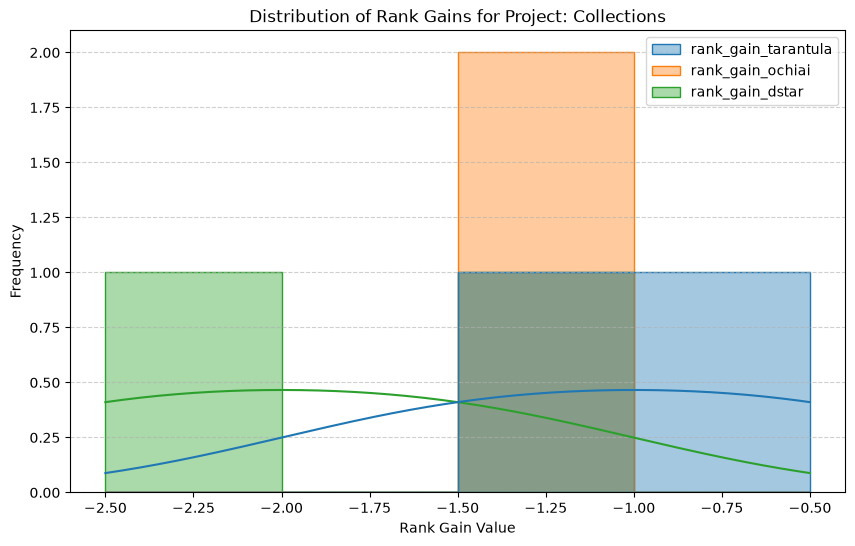

In [41]:
plot_gains_for_project(analysis_df[analysis_df['lambda_val']==1.0], 'Collections')

/var/folders/zp/3681gr8x5mg9vt0z3xbtlzx00000gn/T/ipykernel_128/3837905519.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/zp/3681gr8x5mg9vt0z3xbtlzx00000gn/T/ipykernel_128/3837905519.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/zp/3681gr8x5mg9vt0z3xbtlzx00000gn/T/ipykernel_128/3837905519.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/zp/3681gr8x5mg9vt0z3xbtlzx00000gn/T/ipykernel_128/3837905519.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will 

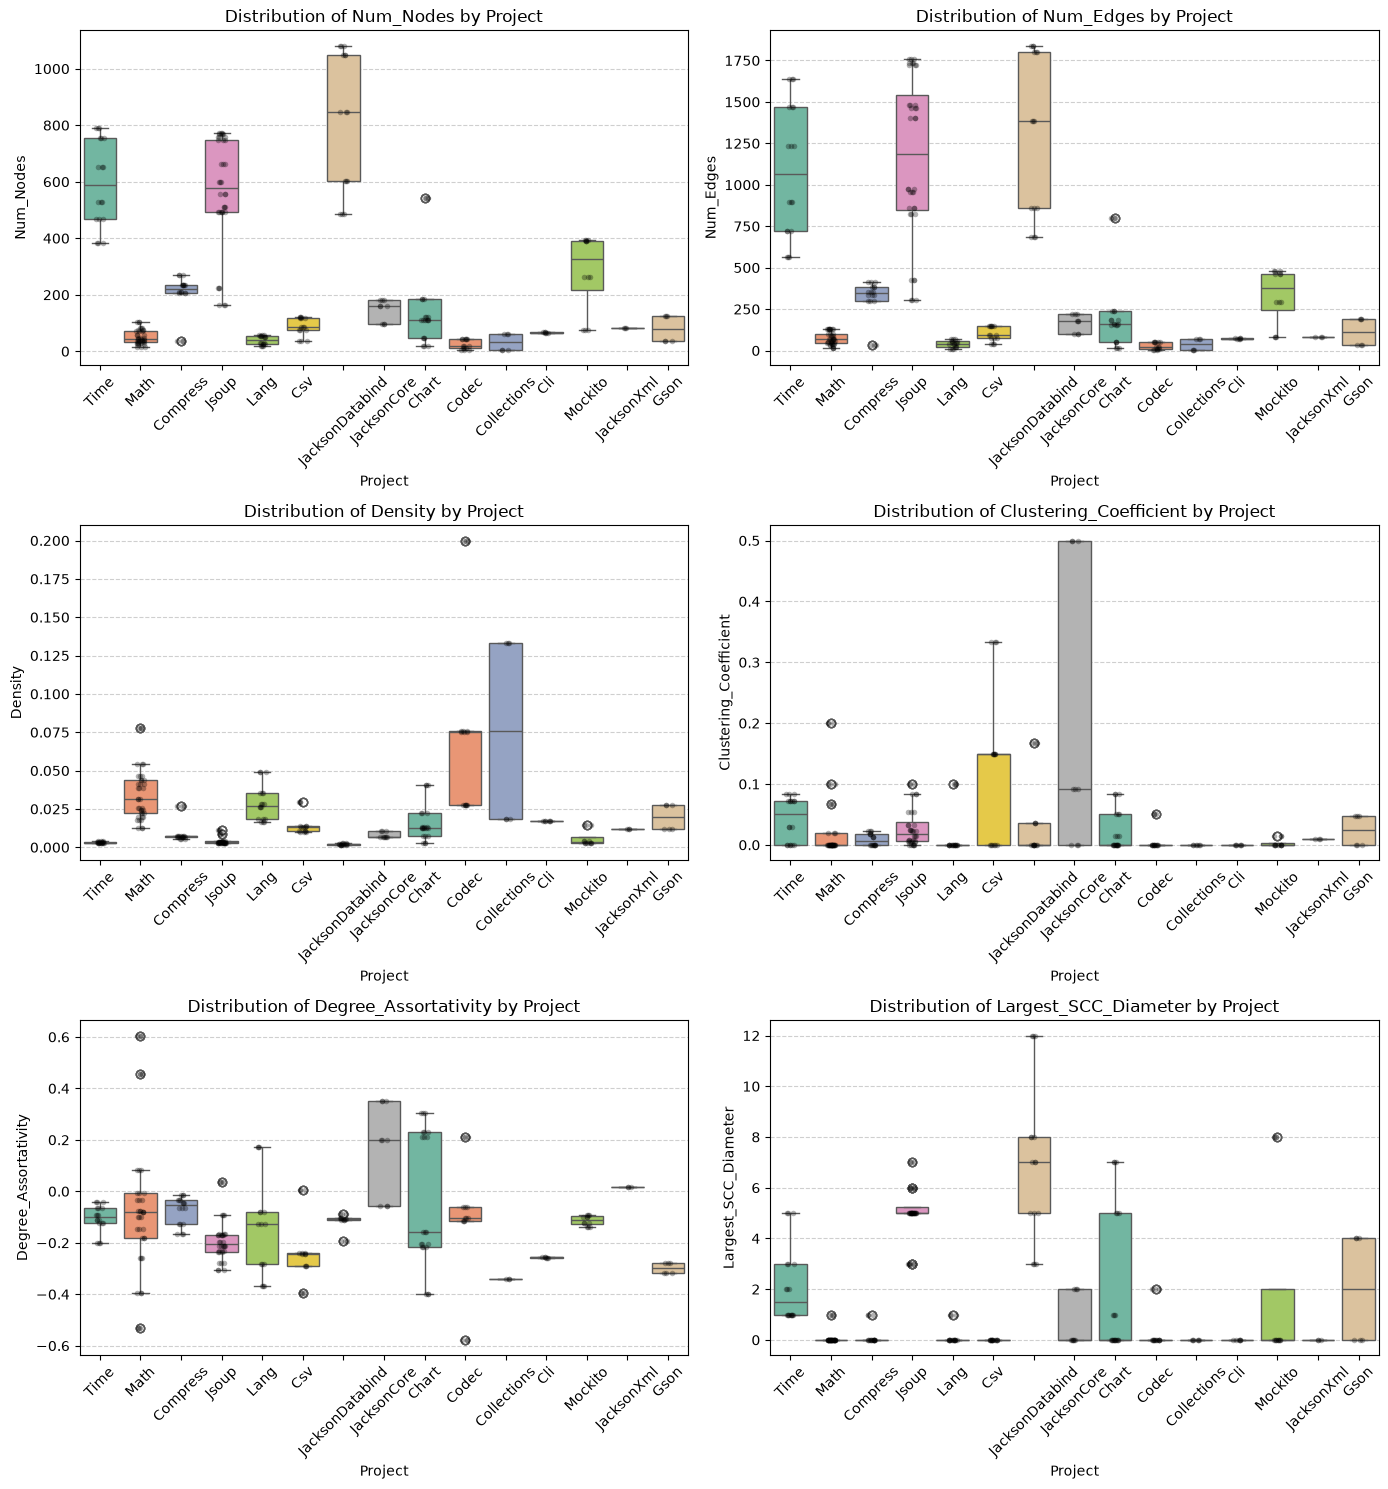

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_graph_metrics_by_project(df, metrics=None):
    """
    Plots the distribution of graph-level metrics grouped by project using boxplots.
    
    Parameters:
    df (pd.DataFrame): Your analysis dataframe.
    metrics (list): A list of column names representing the graph metrics you want to plot. 
                    If None, a default set of structural metrics is used.
    """
    # Define default graph-level metrics if none are specified
    if metrics is None:
        metrics = [
            'Num_Nodes', 
            'Num_Edges', 
            'Density', 
            'Clustering_Coefficient', 
            'Degree_Assortativity',
            'Largest_SCC_Diameter'
        ]
    
    # Filter only for metrics that actually exist in the dataframe
    valid_metrics = [m for m in metrics if m in df.columns]
    
    if not valid_metrics:
        print("No valid graph metrics found in the DataFrame.")
        return

    # Determine the grid size for the subplots (2 columns)
    num_metrics = len(valid_metrics)
    cols = 2
    rows = (num_metrics + 1) // cols
    
    # Create the figure and axes
    fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
    
    # Flatten axes array for easy iteration, especially if it's a 2D array
    if num_metrics > 1:
        axes = axes.flatten()
    else:
        axes = [axes] # Handle single metric case
    
    # Loop through each metric and create a boxplot
    for i, metric in enumerate(valid_metrics):
        sns.boxplot(
            data=df, 
            x='project', 
            y=metric, 
            ax=axes[i], 
            palette='Set2' # A nice default color palette
        )
        
        # Add a jittered scatter plot on top of the boxes to see individual data points
        sns.stripplot(
            data=df, 
            x='project', 
            y=metric, 
            ax=axes[i], 
            color='black', 
            alpha=0.3, 
            size=4
        )
        
        axes[i].set_title(f'Distribution of {metric} by Project')
        axes[i].set_xlabel('Project')
        axes[i].set_ylabel(metric)
        axes[i].tick_params(axis='x', rotation=45) # Rotate x labels for readability
        axes[i].grid(axis='y', linestyle='--', alpha=0.6)
        
    # Remove any extra empty subplots (if the number of metrics is odd)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

# --- Example Usage ---
# Plot the default subset of graph metrics:
plot_graph_metrics_by_project(analysis_df)

# Or, specify exactly which metrics you want to compare:
# my_metrics = ['Num_SCC', 'Num_WCC', 'Reciprocity', 'Largest_SCC_Avg_Path_Length']
# plot_graph_metrics_by_project(analysis_df, metrics=my_metrics)